In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

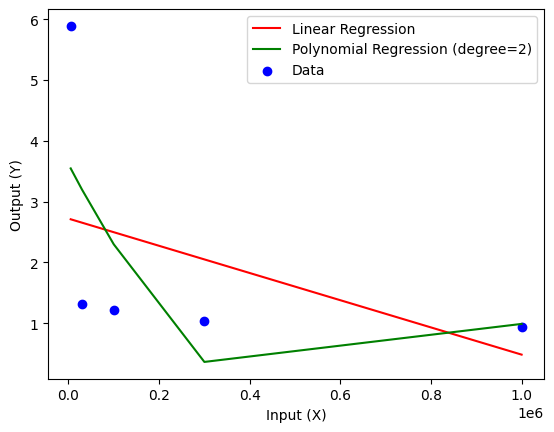

In [12]:

# 假设数据已经给出（这里需要您根据实际情况替换为真实数据）
# 例如，第一行数据（输入）和第二行数据（输出）
X = np.array([5000, 30000, 100000, 300000, 1000000]).reshape(-1, 1)  # 输入数据，注意要reshape为二维数组
Y = np.array([5.89, 1.31, 1.22, 1.03, 0.94])  # 输出数据
 
# 线性回归
linear_model = LinearRegression().fit(X, Y)
linear_Y_pred = linear_model.predict(X)
 
# 多项式回归（例如，二次多项式）
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression()).fit(X, Y)
poly_Y_pred = poly_model.predict(X)
 
# 可视化结果
plt.scatter(X, Y, color='blue', label='Data')
plt.plot(X, linear_Y_pred, color='red', label='Linear Regression')
plt.plot(X, poly_Y_pred, color='green', label='Polynomial Regression (degree=2)')
plt.xlabel('Input (X)')
plt.ylabel('Output (Y)')
plt.legend()
plt.show()

/tmp/ipykernel_1729/1565905235.py:60: RankWarning: Polyfit may be poorly conditioned
  model = RegressionModel(X, Y)
/tmp/ipykernel_1729/1565905235.py:60: RankWarning: Polyfit may be poorly conditioned
  model = RegressionModel(X, Y)


[   6.62138653   10.42285634 -161.12565496]


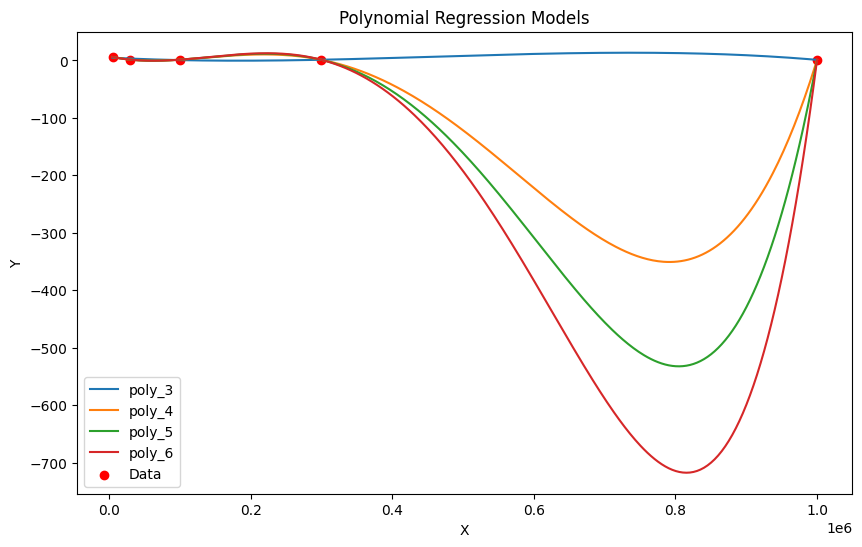

In [16]:
class RegressionModel:
    def __init__(self, X, Y):
        self.X = X.reshape(-1, 1)  # 确保X是二维数组
        self.Y = Y
        self.models = {}
        
        # 拟合多项式回归模型
        for degree in range(3, 7):  # 3到6次多项式
            poly = np.poly1d(np.polyfit(X, Y, degree))
            self.models[f'poly_{degree}'] = lambda x, poly=poly: np.polyval(poly, x)
        
        # 拟合指数回归模型
        def exp_func(x, a, b, c):
            return a * np.exp(b * x) + c
        
        params, _ = curve_fit(exp_func, X, Y, p0=[1, -0.01, 0])  # 初始参数猜测
        self.models['exp'] = lambda x, *params: exp_func(x, *params)
    
    def predict(self, X_new, model_type='poly_3'):
        if model_type not in self.models:
            raise ValueError(f"Model type '{model_type}' not found. Available models: {list(self.models.keys())}")
        return self.models[model_type](X_new)
    
    def plot_polynomial_models(self):
        X_fit = np.linspace(min(self.X), max(self.X), 400).reshape(-1, 1)
        
        plt.figure(figsize=(10, 6))
        for model_type, model in self.models.items():
            if model_type.startswith('poly_'):
                y_fit = model(X_fit)
                plt.plot(X_fit, y_fit, label=model_type)
        
        plt.scatter(self.X, self.Y, color='red', label='Data')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.legend()
        plt.title('Polynomial Regression Models')
        plt.show()
    
    def plot_exponential_model(self):
        X_fit = np.linspace(min(self.X), max(self.X), 400).reshape(-1, 1)
        
        plt.figure(figsize=(10, 6))
        exp_model = self.models['exp']
        y_fit = exp_model(X_fit)
        plt.plot(X_fit, y_fit, label='Exponential Regression')
        
        plt.scatter(self.X, self.Y, color='red', label='Data')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.legend()
        plt.title('Exponential Regression Model')
        plt.show()
 
# 示例数据
X = np.array([5000, 30000, 100000, 300000, 1000000])
Y = np.array([5.89, 1.31, 1.22, 1.03, 0.94])
 
# 创建回归模型实例
model = RegressionModel(X, Y)
 
# 预测新X值的结果（例如，使用五次多项式回归）
X_new = np.array([150000, 250000, 500000])
predictions = model.predict(X_new, model_type='poly_5')
print(predictions)
 
# 绘制多项式回归模型
model.plot_polynomial_models()

/home/zyq0416/workspace/CaL/.venv/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


Predicted Y for X=5000: [2.078]


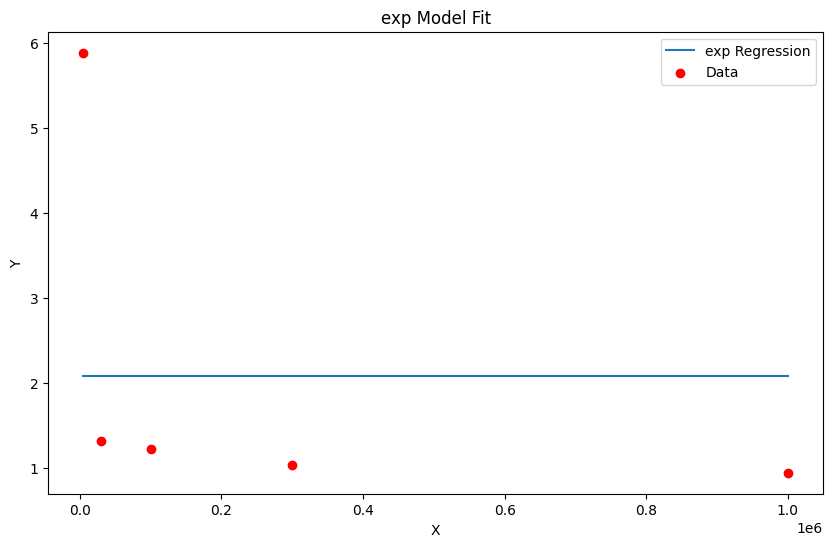

In [17]:
class RegressionFitter:
    def __init__(self, X, Y):
        self.X = X.reshape(-1, 1)  # 确保X是二维数组
        self.Y = Y
        self.models = {}
        
        # 拟合指数回归模型
        def exp_func(x, a, b, c):
            return a * np.exp(b * x) + c
        
        # 使用curve_fit来找到最佳拟合参数
        params, _ = curve_fit(exp_func, X, Y, p0=[1, -0.01, 0])
        self.models['exp'] = (params, exp_func)  # 存储参数和函数
    
    def predict(self, X_new, model_type='exp'):
        if model_type not in self.models:
            raise ValueError(f"Model type '{model_type}' not found. Available models: {list(self.models.keys())}")
        params, func = self.models[model_type]
        return func(X_new, *params)
    
    def plot_model(self, model_type='exp'):
        X_fit = np.linspace(min(self.X), max(self.X), 400).reshape(-1, 1)
        params, func = self.models[model_type]
        y_fit = func(X_fit, *params)
        
        plt.figure(figsize=(10, 6))
        plt.plot(X_fit, y_fit, label=f'{model_type} Regression')
        plt.scatter(self.X, self.Y, color='red', label='Data')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.legend()
        plt.title(f'{model_type} Model Fit')
        plt.show()
 
# 示例数据
X = np.array([5000, 30000, 100000, 300000, 1000000])
Y = np.array([5.89, 1.31, 1.22, 1.03, 0.94])
 
# 创建回归拟合器实例
fitter = RegressionFitter(X, Y)
 
# 预测新X值的结果（例如，X为5000）
X_new = np.array([5000]).reshape(-1, 1)  # 确保X_new是二维数组
predictions = fitter.predict(X_new)
print(f"Predicted Y for X=5000: {predictions[0]}")
 
# 绘制指数回归模型
fitter.plot_model()

Fitted parameters: a = -0.8489452261483602, b = 11.716265253139007
Residual standard deviation: 1.108059160497121
Predicted Y for X=5000: [4.48563475]


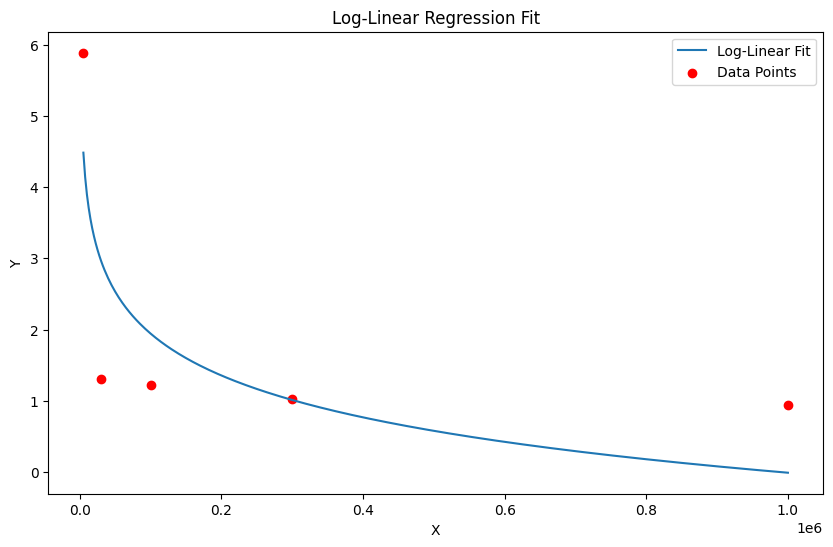

In [39]:
class LogLinearRegressor:
    def __init__(self, X, Y):
        # 确保X是二维数组
        self.X = X.reshape(-1, 1)
        self.Y = Y
        
        # 定义对数线性模型函数
        def log_linear_func(x, a, b):
            return   a* np.log(x) + b
        
        # 使用curve_fit来找到最佳拟合参数
        # 尝试使用不同的初始参数p0
        params, covariance = curve_fit(log_linear_func, X, Y, p0=[5, 5])  # 修改了初始参数
        success = covariance is not None  # 检查curve_fit是否成功
        
        if success:
            self.a, self.b = params  # 存储拟合参数
            self.model_func = log_linear_func  # 存储模型函数
            self.covariance = covariance  # 存储协方差矩阵（可选，用于评估参数不确定性）
        else:
            raise RuntimeError("Curve fit failed.")
        
        # 打印拟合参数和残差信息（可选）
        print(f"Fitted parameters: a = {self.a}, b = {self.b}")
        # 注意：由于curve_fit不直接返回残差，我们需要自己计算它们来检查拟合质量
        residuals = Y - self.model_func(X, *params)
        print(f"Residual standard deviation: {np.std(residuals)}")
    
    def predict(self, X_new):
        # 使用模型函数和拟合参数来预测新的X值对应的Y值
        return self.model_func(X_new, self.a, self.b)
    
    def plot_model(self):
        # 生成用于绘图的X值范围
        X_fit = np.linspace(min(self.X), max(self.X), 400).reshape(-1, 1)
        Y_fit = self.model_func(X_fit, self.a, self.b)
        
        # 绘制数据点和拟合曲线
        plt.figure(figsize=(10, 6))
        plt.scatter(self.X, self.Y, color='red', label='Data Points')
        plt.plot(X_fit, Y_fit, label='Log-Linear Fit')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.legend()
        plt.title('Log-Linear Regression Fit')
        plt.grid(False)
        plt.show()
 
# 示例数据
X = np.array([5000, 30000, 100000, 300000, 1000000])
Y = np.array([5.89, 1.31, 1.22, 1.03, 0.94])
 
# 创建回归拟合器实例
try:
    regressor = LogLinearRegressor(X, Y)
    
    # 预测新X值的结果（例如，X为5000）
    X_new = np.array([5000]).reshape(-1, 1)  # 确保X_new是二维数组
    predicted_Y = regressor.predict(X_new)
    print(f"Predicted Y for X=5000: {predicted_Y[0]}")
    
    # 绘制拟合模型图像
    regressor.plot_model()
except RuntimeError as e:
    print(e)

Fitted parameters: a = -0.8489452208834883, b = 11.716265193929008
Residual standard deviation: 1.108059160497121
Relative errors: [[ 23.84321326 242.41486555 267.67497858 335.49851832 377.19518497]
 [ 49.66843633 126.29993133 142.99418855 187.81835926 215.37543621]
 [ 67.02169538  48.27649939  59.21492968  88.58467399 106.64065341]
 [ 82.8563584   22.91904657  17.23274672   1.96500097   7.42132872]
 [100.20961746 100.9424785  101.0120056  101.19868624 101.31345408]]
Some predictions have relative errors exceeding 1%.
Predicted Y for X=5000: [4.48563474]


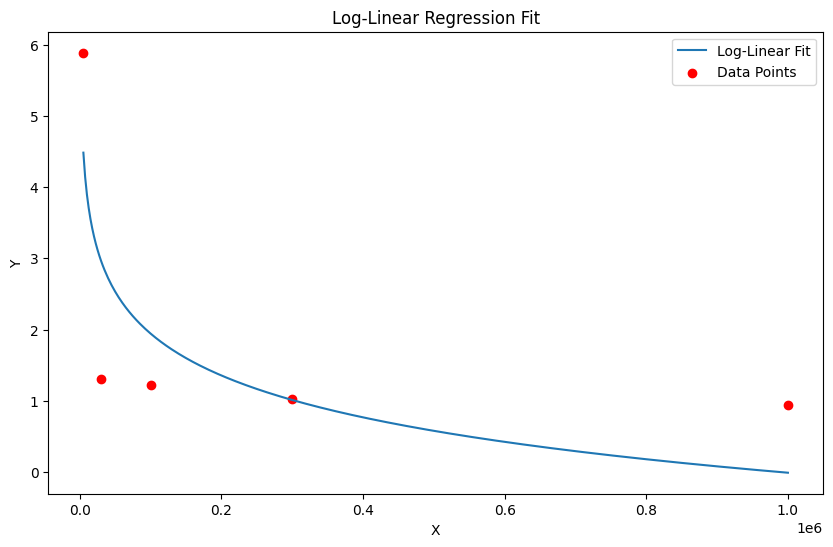

In [42]:
class LogLinearRegressor:
    def __init__(self, X, Y):
        # 确保X是二维数组
        self.X = X.reshape(-1, 1)
        self.Y = Y
        
        # 定义对数线性模型函数
        def log_linear_func(x, a, b):
            return a * np.log(x) + b
        
        # 使用curve_fit来找到最佳拟合参数
        # 尝试使用不同的初始参数p0
        # 注意：这里我调整了初始参数的值，但最佳值通常需要通过实验来确定
        params, covariance = curve_fit(log_linear_func, X, Y, p0=[1e6, 0.94])  # 修改了初始参数
        success = covariance is not None  # 检查curve_fit是否成功
        
        if success:
            self.a, self.b = params  # 存储拟合参数
            self.model_func = log_linear_func  # 存储模型函数
            self.covariance = covariance  # 存储协方差矩阵（可选，用于评估参数不确定性）
        else:
            raise RuntimeError("Curve fit failed.")
        
        # 打印拟合参数和残差信息（可选）
        print(f"Fitted parameters: a = {self.a}, b = {self.b}")
        # 注意：由于curve_fit不直接返回残差，我们需要自己计算它们来检查拟合质量
        residuals = Y - self.model_func(X, *params)
        print(f"Residual standard deviation: {np.std(residuals)}")
        
        # 计算并打印预测的相对误差
        self.calculate_relative_error()
    
    def predict(self, X_new):
        # 使用模型函数和拟合参数来预测新的X值对应的Y值
        return self.model_func(X_new, self.a, self.b)
    
    def calculate_relative_error(self):
        # 计算预测值与实际值之间的相对误差
        predictions = self.model_func(self.X, self.a, self.b)
        relative_errors = np.abs((predictions - self.Y) / self.Y) * 100
        print(f"Relative errors: {relative_errors}")
        # 检查是否所有相对误差都在1%以内
        if np.all(relative_errors < 1):
            print("All predictions have relative errors within 1%.")
        else:
            print("Some predictions have relative errors exceeding 1%.")
    
    def plot_model(self):
        # 生成用于绘图的X值范围
        X_fit = np.linspace(min(self.X), max(self.X), 400).reshape(-1, 1)
        Y_fit = self.model_func(X_fit, self.a, self.b)
        
        # 绘制数据点和拟合曲线
        plt.figure(figsize=(10, 6))
        plt.scatter(self.X, self.Y, color='red', label='Data Points')
        plt.plot(X_fit, Y_fit, label='Log-Linear Fit')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.legend()
        plt.title('Log-Linear Regression Fit')
        plt.grid(False)
        plt.show()
 
# 示例数据
X = np.array([5000, 30000, 100000, 300000, 1000000])
Y = np.array([5.89, 1.31, 1.22, 1.03, 0.94])
 
# 创建回归拟合器实例
try:
    regressor = LogLinearRegressor(X, Y)
    
    # 预测新X值的结果（例如，X为5000）
    X_new = np.array([5000]).reshape(-1, 1)  # 确保X_new是二维数组
    predicted_Y = regressor.predict(X_new)
    print(f"Predicted Y for X=5000: {predicted_Y[0]}")
    
    # 绘制拟合模型图像
    regressor.plot_model()
except RuntimeError as e:
    print(e)